In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [110]:
dataset = pd.read_csv("/content/multiple regression.csv", encoding='latin-1')

In [111]:
dataset.head(3)

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order,Unnamed: 22,Unnamed: 23
0,2018.06.25,25-Jun-2018,2018.0,Boating,USA,California,"Oceanside, San Diego County",Paddling,Julie Wolfe,F,57,"No injury to occupant, outrigger canoe and pad...",N,18h00,White shark,"R. Collier, GSAF",2018.06.25-Wolfe.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.25,2018.06.25,6303.0,NaN,NaN
1,2018.06.18,18-Jun-2018,2018.0,Unprovoked,USA,Georgia,"St. Simon Island, Glynn County",Standing,Adyson McNeely,F,11,Minor injury to left thigh,N,14h00 -15h00,NaN,"K.McMurray, TrackingSharks.com",2018.06.18-McNeely.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.18,2018.06.18,6302.0,NaN,NaN
2,2018.06.09,09-Jun-2018,2018.0,Invalid,USA,Hawaii,"Habush, Oahu",Surfing,John Denges,M,48,Injury to left lower leg from surfboard skeg,N,07h45,NaN,"K.McMurray, TrackingSharks.com",2018.06.09-Denges.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.09,2018.06.09,6301.0,NaN,NaN


In [112]:
dataset.isnull().sum()

,0
Case Number,17021
Date,19421
Year,19423
Type,19425
Country,19471
Area,19876
Location,19961
Activity,19965
Name,19631
Sex,19986


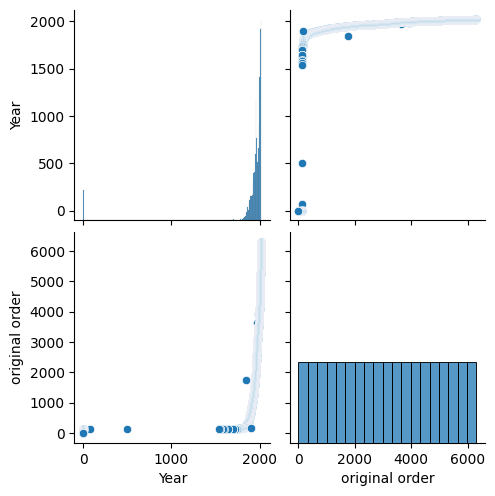

In [114]:
sns.pairplot(data=dataset)
plt.show()

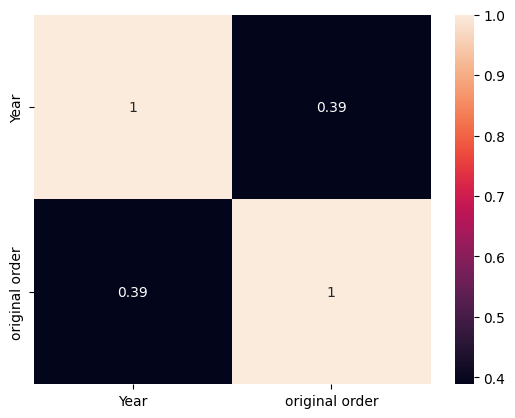

In [117]:
# Select only numeric columns for correlation calculation
numeric_dataset = dataset.select_dtypes(include=['number'])

sns.heatmap(data=numeric_dataset.corr(),annot=True)
plt.show()

In [126]:
x = dataset[['Year']]
y = dataset["original order"]

In [123]:
x.ndim

2

In [120]:
dataset.shape

(25723, 24)

In [119]:
from sklearn.model_selection import train_test_split


In [121]:
x_train , x_test , y_train ,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [124]:
lr = LinearRegression()

In [127]:
# Combine x_train and y_train to easily drop rows with missing values
train_data = pd.concat([x_train, y_train], axis=1)

# Drop rows with missing values in 'Year' or 'original order'
train_data_cleaned = train_data.dropna(subset=['Year', 'original order'])

# Separate the cleaned data back into x_train and y_train
x_train_cleaned = train_data_cleaned[['Year']]
y_train_cleaned = train_data_cleaned['original order']

lr = LinearRegression()
lr.fit(x_train_cleaned, y_train_cleaned)

LinearRegression()

In [132]:
# Combine x_test and y_test to easily drop rows with missing values
test_data = pd.concat([x_test, y_test], axis=1)

# Drop rows with missing values in 'Year' or 'original order'
test_data_cleaned = test_data.dropna(subset=['Year', 'original order'])

# Separate the cleaned data back into x_test and y_test
x_test_cleaned = test_data_cleaned[['Year']]
y_test_cleaned = test_data_cleaned['original order']

lr.score(x_test_cleaned, y_test_cleaned)*100

15.94523694585358

In [130]:
# y = m1x1+m2x2+c

In [133]:
lr.coef_

array([[2.60490905],
       [2.60490905]])

In [134]:
lr.intercept_

array([-1865.83866608, -1865.83866608])

In [137]:
# y_prd = 2.60490905*year 2.60490905*year - 1865.83866608

In [139]:
# Select only the 'Year' column from x_test and drop rows with missing values in 'Year'
x_test_cleaned_for_prediction = x_test[['Year']].dropna(subset=['Year'])

lr.predict(x_test_cleaned_for_prediction)

array([[3218.94379197, 3218.94379197],
       [3260.62233671, 3260.62233671],
       [3385.65797092, 3385.65797092],
       ...,
       [3380.44815283, 3380.44815283],
       [3294.48615431, 3294.48615431],
       [3364.81869856, 3364.81869856]])

In [136]:
x.columns

Index(['Year'], dtype='object')